# **Assignment 1**

Potential things to do:
- In the slide he mentioned something about automatic feature generation -> useful in this case?
- What to do with the nominal features?
- What to do with missing values?
  - Imputation useful?
- What kind of models can be useful?
  - Decision tree / Regression tree
  - The combination of multiple models:
    - First build a model that decides whether a customer will return or not
    - Then apply a model that calculates the revenue for the customers that will return
    - ...
    

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [ ]:
from sklearn.metrics import mean_absolute_error
from scipy import stats

## Test file

In [ ]:
test = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/customer_clv_test.csv')
print(test.shape)
test.head()

(29148, 1)


,cust_id
0,2dfoualegmpt6x2h
1,d2q2stjpnzld7a4r
2,cojscuqlpylhclv2
3,vntezlhi2ryvxk6m
4,jgy4ytjkdr2b75wf


In [ ]:
len(test['cust_id'].unique()  )

29148

#### Revenue file

In [ ]:
revenue = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/customer_clv_train.csv')
print(revenue.shape)
revenue.head()

(116591, 2)


,cust_id,revenue_2018_2019
0,klantwj2374mzmab,209.85
1,a63atwr2ig2jfprr,82.93
2,zr7ihbfbi6gcy2tz,89.95
3,dt7cthjqnjmkbiu6,0.00
4,etcrrgcbrzfovyzj,0.00


In [ ]:
print('The data types of the revenue file are: ')
revenue.dtypes

The data types of the revenue file are: 


,0
cust_id,object
revenue_2018_2019,float64


In [ ]:
len(revenue['cust_id'].unique()  )

116591

With unique we consider the total number of unique customer so if some of the customer_id are repeated we consider them only one time.


#### Transaction file

In [ ]:
transactions_data = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/transactions_2016_2017.csv")
print(transactions_data.shape)
transactions_data.head()

/tmp/ipykernel_5083/3239603760.py:1: DtypeWarning: Columns (8) have mixed types. Specify dtype option on import or set low_memory=False.
  transactions_data = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/transactions_2016_2017.csv")


(344212, 26)


,cust_id,order_date,pack_date,sale_id,sale_discount_applied,sale_revenue,returned_to_shop_id,prod_id,prod_size,prod_web_only,...,prod_type_4,prod_type_5,prod_heel,prod_material,prod_insole,prod_print,prod_comfort_sole,prod_comfort_wear,prod_clasp,prod_outlet
0,klantwj2374mzmab,2016-01-01,2016-01-04,wa46phiwo6neterg,-35.70,83.30,NaN,543rj4mzzjnzkbil,30.0,0,...,NaN,boots (velcro),NaN,leather,1.0,NaN,NaN,NaN,velcro,0
1,klantwj2374mzmab,2016-01-01,2016-01-04,wa46phiwo6neterg,-39.98,0.00,ztodvuuaje,7ewnqhtrquent4cy,44.0,0,...,NaN,dress boots,NaN,leather,0.0,NaN,NaN,NaN,zipper,0
2,a63atwr2ig2jfprr,2016-01-01,2016-01-04,p4y4726y24dcxawf,-24.00,0.00,5tiaacoboa,cwtye5jwqr43a56i,38.5,0,...,high-top sneakers,lace-up shoes,NaN,suede,NaN,NaN,NaN,NaN,NaN,0
3,zr7ihbfbi6gcy2tz,2016-01-01,2016-01-05,3etkl2xv6pxku4kt,-26.23,43.72,NaN,mqw2seipp2wtylnw,35.0,0,...,NaN,velcro shoes,NaN,synthetic leather,0.0,NaN,NaN,breathable,velcro,0
4,dt7cthjqnjmkbiu6,2016-01-01,2016-01-05,lneitdgyfvrie3jo,-29.98,0.00,geja5b25na,5ut47kvr6zlx6y62,25.0,0,...,NaN,boots (velcro),NaN,NaN,NaN,NaN,NaN,NaN,velcro,0


In [ ]:
print('The data types of the transaction file are: ')
transactions_data.dtypes

The data types of the transaction file are: 


,0
cust_id,object
order_date,object
pack_date,object
sale_id,object
sale_discount_applied,float64
sale_revenue,float64
returned_to_shop_id,object
prod_id,object
prod_size,object
prod_web_only,int64


- cust_id: unique identifier of the customer placing the order
- order_date: date when the order was placed
- pack_date: date when the order was packed/shipped
- sale_id: unique identifier of the sales transaction (multiple articles can be present in the same transaction)
- sale_discount_applied: monetary value of discount applied to the sale
- sale_revenue: final revenue amount received for this line item after discount
- returned_to_shop_id: identifier of the shop/location where the item was returned (empty if not returned)
- prod_id: unique identifier of the purchased product
- prod_size: shoe size of the product
- prod_web_only: binary flag (1/0) indicating whether the product is sold online only
- prod_season: season or collection code (e.g., W14 = Winter 2014)
- prod_brand: brand name of the product
- prod_title: full commercial product name/title
- prod_color: primary color of the product
- prod_type_1: primary target group or category (e.g., men, women, boys)
- prod_type_2: not included (= "shoes")
- prod_type_3: secondary product category (e.g., sneakers, high shoes)
- prod_type_4: tertiary style classification (e.g., high-top sneakers)
- prod_type_5: additional style descriptor (e.g., boots with velcro, dress boots)
- prod_heel: heel type or heel specification (if known)
- prod_material: main outer material of the shoe (e.g., leather, suede) (if known)
- prod_insole: indicator of specific insole feature (if known)
- prod_print: type of print or pattern (if known)
- prod_comfort_sole: indicator of special comfort sole feature (if known)
- prod_comfort_wear: indicator of enhanced comfort wear feature (if known)
- prod_clasp: type of closing mechanism (e.g., velcro, zipper, lace-up) (if known)
- prod_outlet: indicator how often this product was sold through an outlet channel, higher values indicate that the product appeared more often

In [ ]:
len(transactions_data['cust_id'].unique()  )

145739

Make the dates a date object:

In [ ]:
transactions_data['order_date'] = pd.to_datetime(transactions_data['order_date'])
transactions_data['pack_date'] = pd.to_datetime(transactions_data['pack_date'])

In [ ]:
transactions_data.describe()

,order_date,pack_date,sale_discount_applied,sale_revenue,prod_web_only,prod_insole,prod_outlet
count,344212,344212,344212.000000,344212.000000,344212.000000,318247.000000,344212.000000
mean,2017-01-21 04:59:20.884571392,2017-01-22 20:23:55.682660608,-20.646063,53.074974,0.229516,0.275456,0.001084
min,2016-01-01 00:00:00,2016-01-03 00:00:00,-200.000000,-200.000000,0.000000,0.000000,0.000000
25%,2016-07-26 00:00:00,2016-07-27 00:00:00,-31.500000,27.000000,0.000000,0.000000,0.000000
50%,2017-01-30 00:00:00,2017-02-02 00:00:00,-12.000000,53.000000,0.000000,0.000000,0.000000
75%,2017-07-14 06:00:00,2017-07-17 00:00:00,-4.590000,75.950000,0.000000,1.000000,0.000000
max,2017-12-31 00:00:00,2018-01-12 00:00:00,1.000000,275.000000,1.000000,1.000000,1.000000
std,NaN,NaN,22.479681,38.108857,0.420522,0.446744,0.032901


## Preprocessing

We have to make a training-validation split

First, filter the test data out of the transaction file:

In [ ]:
# Remove all customers from transactions_data that appear in test
#transactions_filtered = transactions_data[~transactions_data['cust_id'].isin(test['cust_id'])]
#len(transactions_filtered['cust_id'].unique() )

In [ ]:
#transactions_test = transactions_data[transactions_data['cust_id'].isin(test['cust_id'])]
#len(transactions_test['cust_id'].unique() )

Next, make a train-validation split (e.g 15%):

In [ ]:
from sklearn.model_selection import train_test_split

#### Split the revenue file

In [ ]:
revenue_train, revenue_val = train_test_split(revenue, test_size=0.15, random_state=42)

print("Number of train samples:", len(revenue_train))
print("Number of validation samples:", len(revenue_val))

Number of train samples: 99102
Number of validation samples: 17489


#### Split the transaction file

In [ ]:
#transactions_train = transactions_filtered[transactions_filtered['cust_id'].isin(revenue_train['cust_id'])]
#transactions_val = transactions_filtered[transactions_filtered['cust_id'].isin(revenue_val['cust_id'])]

#print("Number of train samples:", len(transactions_train['cust_id'].unique()))
#print("Number of validation samples:", len(transactions_val['cust_id'].unique()))

## Features for our data:

Maybe we should encode our nominal variables (he said something about this in the slides) \
What about the NaN values (sometimes denoted with nan).

Possibilities:
- Customer frequency -> number of purchases ✅
- The total / average revenue for each customers over all of their purchases ✅
- The total / average amount of discounts used over all of their purchases ✅
  - Possible link in the data: people without discounts return more / less than people with discounts
- How many of their orders did they return ✅
  - Possible link in the data: people who returned their (first) order, don't return

Could be useful, but how to represent?
- How much time between their purchases (or between their first and last purchase) ❌ -> does not work, see below
- Do they purchase around specific times / seasons / months / etc -> we can extract the month maybe?
- Preference for specific products
- How many purchases in 2016 vs 2017 ❌ -> also not possible
  



---



#### Money features
Below you find some features for the money-related fields:
- The total revenue for each customer
- The average revenue over their orders
- Their amount of orders
- The sum of all of their discounts
- The average amount of discounts over all of their orders (so not over the number of orders where they applied a discount)
- The number of discounts used
- Their return rate -> What percentage of their orders did they return

In [ ]:
transactions_data['is_returned'] = transactions_data['returned_to_shop_id'].notna()

transactions_data['net_revenue'] = transactions_data['sale_revenue']
transactions_data.loc[transactions_data['is_returned'], 'net_revenue'] = 0

In [ ]:
money_features = transactions_data.groupby('cust_id').agg({
    'sale_revenue': ['sum', 'mean', 'count'],
    'sale_discount_applied': ['sum', 'mean', lambda x: (x != 0).sum()],
    'returned_to_shop_id': lambda x: x.notna().mean()
})

money_features.columns = [
    'total_revenue',
    'avg_order_value',
    'order_count',
    'total_discount',
    'avg_discount',
    'number_of_discounts',
    'return_rate'
]

money_features = money_features.reset_index()

print(money_features.shape)
money_features.head()

(145739, 8)


,cust_id,total_revenue,avg_order_value,order_count,total_discount,avg_discount,number_of_discounts,return_rate
0,222agnowc53dykbq,89.95,89.950000,1,0.00,0.000000,0,0.000000
1,222ny4m63rmalpdl,125.93,41.976667,3,-45.16,-15.053333,3,0.333333
2,222wlefm7esnsi3h,157.32,78.660000,2,-28.58,-14.290000,2,0.000000
3,223jend5smd4ptmc,89.95,89.950000,1,0.00,0.000000,0,0.000000
4,223xvc4rbjatlnev,116.14,58.070000,2,-49.76,-24.880000,2,0.000000


Train-validation split:

In [ ]:
#money_train = money_features[money_features['cust_id'].isin(revenue_train['cust_id'])]
#money_val = money_features[money_features['cust_id'].isin(revenue_val['cust_id'])]
#money_test = money_features[money_features['cust_id'].isin(test['cust_id'])]



---


#### Time features:
Below you find some features for the time-related fields: \
Can be expanded.

In [ ]:
time_features1 = transactions_data.groupby('cust_id').agg(
    first_date=('order_date', 'min'),
    last_date=('order_date', 'max') )

time_features1['first_date'] = pd.to_datetime(time_features1['first_date'])
time_features1['last_date'] = pd.to_datetime(time_features1['last_date'])

time_features1['lifetime'] = (
    time_features1['last_date'] - time_features1['first_date']
).dt.days

print(time_features1.shape)
time_features1.head()

(145739, 3)


,first_date,last_date,lifetime
cust_id,,,
222agnowc53dykbq,2016-12-13,2016-12-13,0
222ny4m63rmalpdl,2016-12-22,2016-12-22,0
222wlefm7esnsi3h,2017-12-13,2017-12-13,0
223jend5smd4ptmc,2016-08-30,2016-08-30,0
223xvc4rbjatlnev,2016-07-29,2016-07-29,0


In [ ]:
len(time_features1[(time_features1['lifetime']  > 0 )] )

48335



---
#### Second try: (time features)
Features:
- Year of purchase(s) ✅
- Month of purchase(s) ✅
- Day of purchase(s) ✅

Other options:
- Is the date around a holiday? Christmas, Easter, ...
- Recency

In [ ]:
time_features = transactions_data.groupby('cust_id')['order_date'].min().reset_index()

time_features['year'] = time_features['order_date'].dt.year
time_features['month'] = time_features['order_date'].dt.month
time_features['day'] = time_features['order_date'].dt.day

In [ ]:
time_features

,cust_id,order_date,year,month,day
0,222agnowc53dykbq,2016-12-13,2016,12,13
1,222ny4m63rmalpdl,2016-12-22,2016,12,22
2,222wlefm7esnsi3h,2017-12-13,2017,12,13
3,223jend5smd4ptmc,2016-08-30,2016,8,30
4,223xvc4rbjatlnev,2016-07-29,2016,7,29
...,...,...,...,...,...
145734,zzz7uiqp6ouwud4l,2016-02-27,2016,2,27
145735,zzzia37zqscfec3n,2016-01-02,2016,1,2
145736,zzzkqzcsvt5byq36,2017-10-06,2017,10,6
145737,zzzs2uu7fwbcmuyf,2017-10-08,2017,10,8


In [ ]:
#time_train = time_features[time_features['cust_id'].isin(revenue_train['cust_id'])]
#time_val = time_features[time_features['cust_id'].isin(revenue_val['cust_id'])]
#time_test = time_features[time_features['cust_id'].isin(test['cust_id'])]

# Product Features


In [ ]:
product_features=transactions_data.groupby('cust_id').agg({
    'prod_web_only':'mean',
    'prod_outlet': 'mean',
    'prod_insole':'mean',
    'prod_brand':'nunique',
    'prod_type_3': 'nunique'
})
product_features.columns=['perc_web_only', 'perc_outlet', 'perc_special_insole', 'num_different_brands', 'num_different_shoe_types']
product_features=product_features.reset_index()
product_features.head()

,cust_id,perc_web_only,perc_outlet,perc_special_insole,num_different_brands,num_different_shoe_types
0,222agnowc53dykbq,0.0,0.0,1.000000,1,1
1,222ny4m63rmalpdl,0.0,0.0,0.666667,2,2
2,222wlefm7esnsi3h,0.0,0.0,0.000000,2,2
3,223jend5smd4ptmc,0.0,0.0,0.000000,1,1
4,223xvc4rbjatlnev,0.0,0.0,0.000000,1,1


CAVEAT: 0 if all the shoes bought by the client are sold only online, for the outlet case 0 if all the shoes bought by the client are sold only inside outlets.

Now we try to merge time, money and product.

In [ ]:
complete_table=pd.merge(money_features, product_features, on='cust_id', how='left')
complete_table=complete_table.fillna(0)
complete_table.head()

,cust_id,total_revenue,avg_order_value,order_count,total_discount,avg_discount,number_of_discounts,return_rate,perc_web_only,perc_outlet,perc_special_insole,num_different_brands,num_different_shoe_types
0,222agnowc53dykbq,89.95,89.950000,1,0.00,0.000000,0,0.000000,0.0,0.0,1.000000,1,1
1,222ny4m63rmalpdl,125.93,41.976667,3,-45.16,-15.053333,3,0.333333,0.0,0.0,0.666667,2,2
2,222wlefm7esnsi3h,157.32,78.660000,2,-28.58,-14.290000,2,0.000000,0.0,0.0,0.000000,2,2
3,223jend5smd4ptmc,89.95,89.950000,1,0.00,0.000000,0,0.000000,0.0,0.0,0.000000,1,1
4,223xvc4rbjatlnev,116.14,58.070000,2,-49.76,-24.880000,2,0.000000,0.0,0.0,0.000000,1,1


# Recency:

In [ ]:
import pandas as pd

In [ ]:
transactions_data['order_date']=pd.to_datetime(transactions_data['order_date'])
main_data=pd.to_datetime('2017-12-31')
recency_features=transactions_data.groupby('cust_id').agg({'order_date': lambda x: (main_data-x.max()).days}).reset_index()
recency_features.columns=['cust_id', 'recency_days']
print('An example of Recency: ')
print(recency_features.head())

An example of Recency: 
            cust_id  recency_days
0  222agnowc53dykbq           383
1  222ny4m63rmalpdl           374
2  222wlefm7esnsi3h            18
3  223jend5smd4ptmc           488
4  223xvc4rbjatlnev           520


Now we can merge also recency in the table.

In [ ]:
#train_time_money = money_train.merge(time_train, on='cust_id', how='left') \
                             # .merge(product_features, on='cust_id', how='left') \
                              #.merge(recency_features, on='cust_id', how='left')

#val_time_money = money_val.merge(time_val, on='cust_id', how='left') \
                        #    .merge(product_features, on='cust_id', how='left') \
                        #    .merge(recency_features, on='cust_id', how='left')

#test_time_money = money_test.merge(time_test, on='cust_id', how='left') \
                         #     .merge(product_features, on='cust_id', how='left') \
                     #         .merge(recency_features, on='cust_id', how='left')

#train_time_money = train_time_money.fillna(0)
#val_time_money = val_time_money.fillna(0)
#test_time_money = test_time_money.fillna(0)

#X_train_xgb = train_time_money.drop(columns=['cust_id', 'order_date'])
#X_val_xgb = val_time_money.drop(columns=['cust_id', 'order_date'])
#X_test_xgb = test_time_money.drop(columns=['cust_id', 'order_date'])

# Outliers

CAVEAT: if we want to remove the outliers from the money features we run the following code:

In [ ]:
money_featuresnoutliers=money_features[money_features['order_count']<=50]

In [ ]:
#money_trainnooutliers=money_train[money_train['order_count']<100]

We have removed customers who have done crazy orders just like ordering more 50 shoes, since this is not common or 'normal'.

I am not sure about this: I think that for the train data we should be using the one without outliers so the algorithm is able to learn how consumers usually behave, on the other hand for the test set is better to use the one with outliers since we are using our dataset.
Under you can find the code and check if it actually makes sense and gives better results.

In [ ]:
#ADDED CELL TO FIND A SOLUTION TO THE PROBLEM
master_features = money_features.merge(time_features, on='cust_id', how='left') \
                                .merge(product_features, on='cust_id', how='left') \
                                .merge(recency_features, on='cust_id', how='left')


money_features_no_outliers = money_features[money_features['order_count'] < 100]

master_features_no_outliers = money_features_no_outliers.merge(time_features, on='cust_id', how='left') \
                                                        .merge(product_features, on='cust_id', how='left') \
                                                        .merge(recency_features, on='cust_id', how='left')


train_aligned = revenue_train.merge(master_features_no_outliers, on='cust_id', how='inner').fillna(0)

X_train_xgb1 = train_aligned.drop(columns=['cust_id', 'revenue_2018_2019', 'order_date'], errors='ignore')
Y_train_xgb1 = train_aligned['revenue_2018_2019']


val_aligned = revenue_val.merge(master_features, on='cust_id', how='left').fillna(0)

X_val_xgb1 = val_aligned.drop(columns=['cust_id', 'revenue_2018_2019', 'order_date'], errors='ignore')
Y_val_xgb1 = val_aligned['revenue_2018_2019']


test_aligned = test.merge(master_features, on='cust_id', how='left').fillna(0)

X_test_xgb1 = test_aligned.drop(columns=['cust_id', 'order_date'], errors='ignore')


X_test_xgb1 = X_test_xgb1[X_train_xgb1.columns]

## Visualizations of our data

Histogram of the revenues:

In [ ]:
plt.hist(revenue['revenue_2018_2019'], bins=[0, 5, 100, 200, 300, 400, 600, 800, 1000, 1100, 1200])
plt.title('Histogram of revenues (2018-2019)')
plt.xlabel('Revenue')
plt.show()

-> A lot of customers have revenue 0, what to do with those? \
-> These are probably the non-returning customers (heavy customer churn->one-off shoppers), it is useful to use a classfier to predict if a customer returns and if yes how much he will spend the next time.


In [ ]:
print('Number of zero revenue customers: ', len(revenue[ revenue['revenue_2018_2019'] ==  0 ]  ) )

In [ ]:
plt.hist(money_features['order_count']) #  bins = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 15, 20, 30, 50, 75, 100]
plt.yscale('log')
plt.title('Something')
plt.xlabel('Number of orders')
plt.show()

In [ ]:
print(money_features['order_count'].describe())

In [ ]:
outlierid=money_features[money_features['order_count']==142]['cust_id'].iloc[0]
outlier_transactions=transactions_data[transactions_data['cust_id']==outlierid]
print(f"the client has done 142 orders in {outlier_transactions['order_date'].nunique()} different days ")

On average, people ordered 2 (rounded) times. There apparantly was someone who ordered 142 times. 🤨->(this value can be considered an outlier). Possible reasons: a reseller, a bot or a glitch of the system or an extremely rich customer (anyway a kind of not common situation)

In [ ]:
len(money_features[(money_features['order_count']  >= 10) & (money_features['order_count']  <= 20)] )

In [ ]:
plt.hist(time_features1['lifetime']) #  bins = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 15, 20, 30, 50, 75, 100]
plt.title('Something')
plt.xlabel('Number of orders')
plt.show()

### Seasonal effects:

In [ ]:
train_data = money_features.merge(time_features, on='cust_id', how='left')

In [ ]:
monthly_orders = ( train_data.groupby(['year', 'month']).agg(total_orders=('order_count', 'sum'),total_revenue=('total_revenue', 'sum') ).reset_index() )

Below you can find 2 histograms that show that the amount of orders \
The revenue made in January or July is larger than in other months. \
Business Context: we are studying a European fashion retail market so it is easy to notice that these one are the sales' months(Winter and Summer clearence sales). This kind of client is called Bargain Hunters they are price sensitive->they usually wait for discounts and usually shop during sales or in outlets. They have a different kind of custorer lifetime value and returning probability compared to a customer who buys at full price(they are not fully intrested in your shop or product but mainly on the discount).

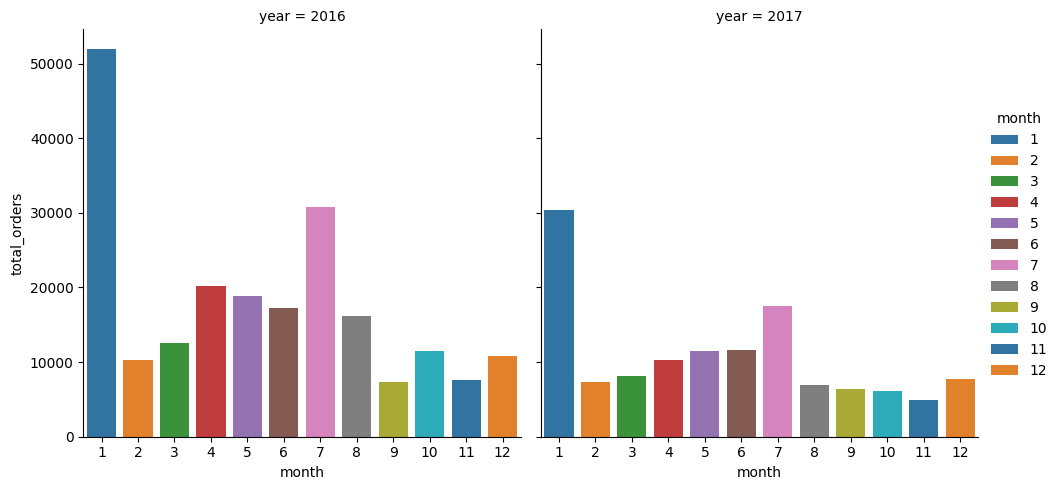

In [ ]:
sns.catplot( x='month', y='total_orders', col='year', data=monthly_orders, kind='bar', errorbar=None, hue='month', palette='tab10' )

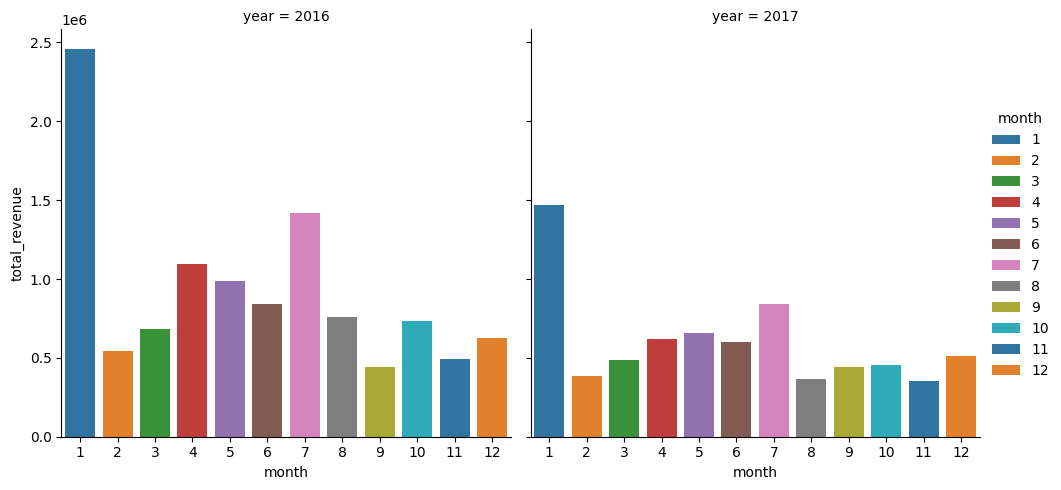

In [ ]:
sns.catplot( x='month', y='total_revenue', col='year', data=monthly_orders, kind='bar', errorbar=None, hue='month', palette='tab10' )

We can notice a decrease in the orders from 2016 to 2017, as a consequence the same happens for the revenue. We have a decline in total order volume, this suggest a potential issue with customer retention(churn->shoppers of the first year do not return in the second). It may be bcause less powerful sales in the sale month, other european e-commerce compentitor or political situations/external macro economics situations. In June 2016 the Brexit referendum won( causing a loss in trust), new arising competitors like Amazon and Zalando, change in the mentality with an increasing interest in more sustainable customers compared to fast fashion.

In [ ]:
returning_customers = revenue[ revenue['revenue_2018_2019'] != 0]

In [ ]:
df_returning = time_features.copy()

df_returning['returned_2018_2019'] = df_returning['cust_id'].isin(returning_customers['cust_id'])

df_returning

,cust_id,order_date,year,month,day,returned_2018_2019
0,222agnowc53dykbq,2016-12-13,2016,12,13,False
1,222ny4m63rmalpdl,2016-12-22,2016,12,22,False
2,222wlefm7esnsi3h,2017-12-13,2017,12,13,False
3,223jend5smd4ptmc,2016-08-30,2016,8,30,False
4,223xvc4rbjatlnev,2016-07-29,2016,7,29,False
...,...,...,...,...,...,...
145734,zzz7uiqp6ouwud4l,2016-02-27,2016,2,27,True
145735,zzzia37zqscfec3n,2016-01-02,2016,1,2,False
145736,zzzkqzcsvt5byq36,2017-10-06,2017,10,6,False
145737,zzzs2uu7fwbcmuyf,2017-10-08,2017,10,8,False


In [ ]:
returning_summary = (
    df_returning.groupby(['year', 'month'])['returned_2018_2019']
             .sum()  # counts True = returning customers
             .reset_index(name='returning_customers')
)

In [ ]:
returning_summary['total'] = (train_data.groupby(['year', 'month'])['cust_id'].count().reset_index(name='total'))['total']
returning_summary['%returned'] = returning_summary['returning_customers'] / returning_summary['total']

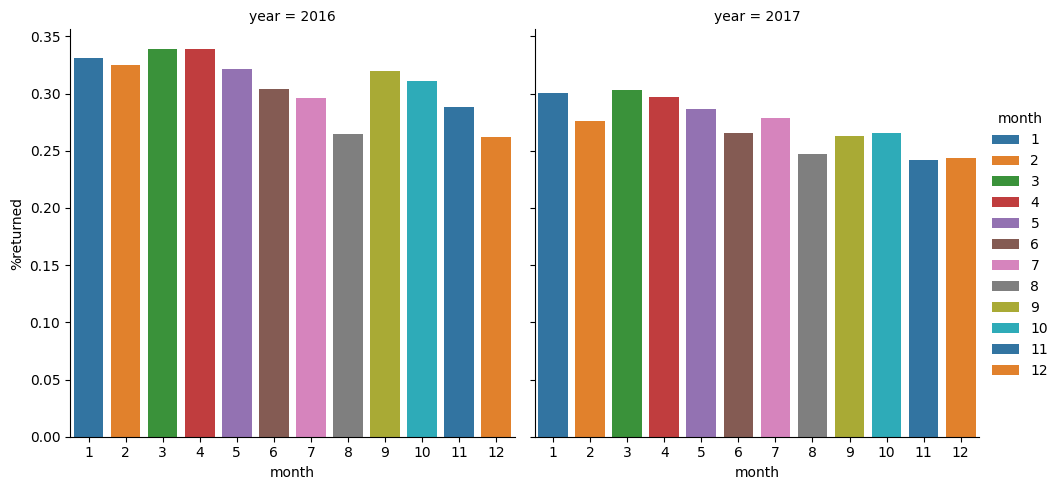

In [ ]:
sns.catplot( x='month', y='%returned', col='year', data=returning_summary, kind='bar', errorbar=None, hue='month', palette='tab10' )

The chart displays the monthly return rate. During sales not only the orders increase as we have seen before but also the returns arriving to 30-34% this show us customers buy in a more impulsive way during sales month->high order months are risky for logistic(because of returns since it is an e-commerce) and net profit. The return rate is fundamental in order to calculate the lifetime value. In fact a client with a smaller percentage of return is better than one with an higher one.

## Models

- Decision tree maybe?
- Plain (linear) regression (with or without ridge / lasso)
- Combination of multiple models
  - Classification (Will a customer buy?) + Regression (How much, if they buy?) -> Multiply probability × predicted revenue
- Random Forest
- LightGBM
- CatBoost
- ...

---

### Regression tree (only on the money features yet):

Very quick attempt at using a regression tree:

In [ ]:
##from sklearn import tree

# Merge money_features with revenue to align features and target for training
##training_data = pd.merge(money_train, revenue_train, on='cust_id', how='inner')

# Define X_train (features) and Y_train (target)
# Exclude 'cust_id' from the features as it's a string identifier
##X_train = training_data[money_train.columns.drop('cust_id')] # Use all 7 features from money_features
##Y_train = training_data['revenue_2018_2019']

##clf = tree.DecisionTreeRegressor()
##clf = clf.fit(X_train, Y_train)

In [ ]:
from sklearn import tree

X_train = X_train_xgb1
Y_train = Y_train_xgb1

clf = tree.DecisionTreeRegressor(max_depth=5)
clf = clf.fit(X_train, Y_train)

In [ ]:
X_val = X_val_xgb1
validation = clf.predict(X_val)

In [ ]:
####X_val = money_val[money_train.columns.drop('cust_id')]

#######validation = clf.predict(X_val)

In [ ]:
vals = revenue_val['revenue_2018_2019'] - validation
vals

,revenue_2018_2019
50523,223.640549
49516,38.539046
89035,-39.544794
90943,-39.544794
100638,-93.322612
...,...
21375,-2.109489
89703,-84.667901
115352,-39.544794
31590,-24.970759


In [ ]:
zeros = vals[ (vals <= 5) & (vals >= -5)]
len(zeros)

258

In [ ]:
len(  revenue_val[ revenue_val['revenue_2018_2019'] == 0 ])

11028

In [ ]:
MAE = mean_absolute_error(revenue_val['revenue_2018_2019'], validation)
spearman = stats.spearmanr(revenue_val['revenue_2018_2019'], validation)

print("Mean Absolute Error for validation set:", MAE)
print("Spearman correlation for validation set:", spearman.statistic)

Mean Absolute Error for validation set: 78.46439794881515
Spearman correlation for validation set: 0.37664295457477703


We have poor predictive performance with this tree. The Spearmann close to 0 implies that the model is not ablt to rank customers correclty, in the meanwhile the 109 euro per customer is an high value in footwear retail it shows that it deviate strongly from actual spending. This might be because overfitting(so we can try with a maximum depth), a lot of vustomer have a target revenue of 0, so a standard regressor struggle to predict the probability both of returning and amount spent. We try to impose a Hyperparameter Tuning to prevent the overfitting with the maximum depth.

In [ ]:
clf=tree.DecisionTreeRegressor(max_depth=5)
clf=clf.fit(X_train, Y_train)
validation=clf.predict(X_val)
MAE=mean_absolute_error(revenue_val['revenue_2018_2019'], validation)
spearman=stats.spearmanr(revenue_val['revenue_2018_2019'], validation)
print('MAE', MAE)
print('Spearman:', spearman)

MAE 78.46439794881515
Spearman: SignificanceResult(statistic=np.float64(0.37664295457477703), pvalue=np.float64(0.0))


We have tried with a maxdepth, we can notice a slightly improvment in the MAE but although that the models still does not work well, look at the value of p-value>0.05. This is because of the zero inflatation because of clients who have decided to never come back. So we have to change the method.

In [ ]:
# Prepare X_test for prediction by selecting money_features for the test customers
# Merge 'test' dataframe with 'money_features' to get features for test customers
# 'how='left'' ensures all test customers are included, and if a customer has no money_features,
# their feature values will be NaN.
# .fillna(0) then replaces these NaNs with 0, consistent with the original reindex's fill_value.
#X_test = pd.merge(test, money_test, on='cust_id', how='left').fillna(0)

# Drop the 'cust_id' column as it was not used for training the model.
# Also, ensure the column order matches X_train by selecting only the trained feature columns.
X_test = X_test_xgb1

result = clf.predict(X_test)

In [ ]:
print(len(result[ result == 0]) )

0


In [ ]:
importances = clf.feature_importances_

In [ ]:
importances

array([7.18605842e-01, 0.00000000e+00, 1.98827485e-02, 3.53082461e-04,
       0.00000000e+00, 2.03538255e-03, 0.00000000e+00, 0.00000000e+00,
       8.33682029e-04, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 7.77326197e-03, 1.73199222e-01, 7.73167785e-02])

Those values show the poor Spearmann correlation and high MAE, in fact the different values in the array shows hat this imbalance is a sign of model over-simplification -> since the tree ignores some kind of behaviors like return sales and seasonal purchasing the three fails to capture the real behaviour of the customer.



---

### XGBoost:

In [ ]:
from xgboost import XGBRegressor
from xgboost.callback import EarlyStopping

In [ ]:
#train_time_money = money_train.merge(time_train, on='cust_id', how='left')
#val_time_money = money_val.merge(time_val, on='cust_id', how='left')
#test_time_money = money_test.merge(time_test, on='cust_id', how='left')

# Drop non-numeric and identifier columns from the feature sets
# cust_id is an identifier and order_date has been converted to year/month/day
#X_train_xgb = train_time_money.drop(columns=['cust_id', 'order_date'])
#Y_train_xgb = revenue_train['revenue_2018_2019']

#X_val_xgb = val_time_money.drop(columns=['cust_id', 'order_date'])
#Y_val_xgb = revenue_val['revenue_2018_2019']

#X_test_xgb = test_time_money.drop(columns=['cust_id', 'order_date'])
#

X_train_xgb = X_train_xgb1
Y_train_xgb = Y_train_xgb1

X_val_xgb = X_val_xgb1
Y_val_xgb = Y_val_xgb1

X_test_xgb = X_test_xgb1

🔽 Can maybe improve with some tuning

In [ ]:
model = XGBRegressor(
    objective="reg:absoluteerror",
    n_estimators=500,
    learning_rate=0.05,
    max_depth=5,
    early_stopping_rounds=50,
    eval_metric="mae",
    random_state=42,
    tree_method="hist",
)

model.fit(X_train_xgb, Y_train_xgb,
    eval_set=[(X_val_xgb, Y_val_xgb)],
    verbose=True
)

[0]	validation_0-mae:70.73258
[1]	validation_0-mae:70.22318
[2]	validation_0-mae:69.71119
[3]	validation_0-mae:69.21685
[4]	validation_0-mae:68.75467
[5]	validation_0-mae:68.34090
[6]	validation_0-mae:67.96529
[7]	validation_0-mae:67.61281
[8]	validation_0-mae:67.30195
[9]	validation_0-mae:67.00413
[10]	validation_0-mae:66.72203
[11]	validation_0-mae:66.46019
[12]	validation_0-mae:66.21823
[13]	validation_0-mae:66.00937
[14]	validation_0-mae:65.81978
[15]	validation_0-mae:65.62813
[16]	validation_0-mae:65.44805
[17]	validation_0-mae:65.28933
[18]	validation_0-mae:65.13511
[19]	validation_0-mae:64.99872
[20]	validation_0-mae:64.88398
[21]	validation_0-mae:64.76553
[22]	validation_0-mae:64.66832
[23]	validation_0-mae:64.56380
[24]	validation_0-mae:64.47420
[25]	validation_0-mae:64.39274
[26]	validation_0-mae:64.32617
[27]	validation_0-mae:64.25250
[28]	validation_0-mae:64.19751
[29]	validation_0-mae:64.13471
[30]	validation_0-mae:64.08272
[31]	validation_0-mae:64.03495
[32]	validation_0-

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=50,
             enable_categorical=False, eval_metric='mae', feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=500,
             n_jobs=None, num_parallel_tree=None, ...)

ValueError: DataFrame.dtypes for data must be int, float, bool or category. When categorical type is supplied, the experimental DMatrix parameter`enable_categorical` must be set to `True`.  Invalid columns:cust_id: object, order_date: datetime64[ns]

In [ ]:
validation = model.predict(X_val_xgb)

In [ ]:
MAE = mean_absolute_error(revenue_val['revenue_2018_2019'], validation)
spearman = stats.spearmanr(revenue_val['revenue_2018_2019'], validation)

print("Mean Absolute Error for validation set:", MAE)
print("Spearman correlation for validation set:", spearman.statistic)

Mean Absolute Error for validation set: 63.44126068904313
Spearman correlation for validation set: 0.38929329619108854


we have an algoritm update but the value of the mae and spearmann are still not good because the zero inflation problem so clients who decided to not comeback spending 0 euros, we notice that the problem is the target audience

In [ ]:
result = model.predict(X_test_xgb)

In [ ]:
len(result[ result != 0]  )

8870

In [ ]:
importances = model.feature_importances_
importances

array([0.01330045, 0.00871446, 0.6794732 , 0.01352775, 0.01043801,
       0.02100622, 0.0114755 , 0.03183901, 0.03420096, 0.007241  ,
       0.00697389, 0.00549126, 0.00385353, 0.0754554 , 0.03639681,
       0.04061254], dtype=float32)

In [ ]:
X_train_xgb

,total_revenue,avg_order_value,order_count,total_discount,avg_discount,number_of_discounts,return_rate,year,month,day,perc_web_only,perc_outlet,perc_special_insole,num_different_brands,num_different_shoe_types,recency_days
0,31.96,31.960000,1,-7.99,-7.990000,1,0.000000,2017,1,15,1.000000,0.0,1.000000,1,1,350
1,110.00,110.000000,1,0.00,0.000000,0,0.000000,2017,2,5,0.000000,0.0,1.000000,1,1,329
2,63.00,63.000000,1,-26.95,-26.950000,1,0.000000,2016,8,2,1.000000,0.0,0.000000,1,1,516
3,78.00,78.000000,1,-52.00,-52.000000,1,0.000000,2017,7,27,0.000000,0.0,1.000000,1,1,157
4,80.95,80.950000,1,-9.00,-9.000000,1,0.000000,2017,4,25,0.000000,0.0,0.000000,1,1,250
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99097,62.95,20.983333,3,-42.00,-14.000000,2,0.666667,2017,4,7,0.333333,0.0,0.000000,3,3,34
99098,232.05,77.350000,3,-25.80,-8.600000,3,0.000000,2017,11,11,0.000000,0.0,0.666667,1,1,50
99099,75.95,75.950000,1,0.00,0.000000,0,0.000000,2017,9,12,0.000000,0.0,0.000000,1,1,110
99100,72.45,24.150000,3,-107.45,-35.816667,3,0.333333,2016,1,3,0.000000,0.0,0.000000,3,2,536


at the end the variable return is a significant predictor infact it confirms that the behaviour of the customer is more predictive than the gross volume->we notice again the impact of Bargain Hunters.



---

### Combining 2 models

In [ ]:
from xgboost import XGBClassifier
from xgboost.callback import EarlyStopping

In [ ]:
returned = revenue.copy()
returned['returning'] = (revenue['revenue_2018_2019'] != 0).astype(int)

returned_train = returned[ returned['cust_id'].isin(revenue_train['cust_id']) ]
returned_val = returned[ returned['cust_id'].isin(revenue_val['cust_id'])  ]

In [ ]:
returned_train['returning'].value_counts(normalize=True)

,proportion
returning,
0,0.63475
1,0.36525


63% is composed by clients who never returns(revenue=0), while the 36% come back.

In [ ]:
from collections import Counter

counter = Counter(returned_train['returning'])
scale_pos_weight = counter[0] / counter[1]

In [ ]:
model = XGBClassifier(
    n_estimators=400,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1,
  #scale_pos_weight=scale_pos_weight,
    eval_metric="aucpr",
    random_state=42,
    min_child_weight = 5
)

model.fit(X_train_xgb, returned_train['returning'] )

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='aucpr', feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
              max_leaves=None, min_child_weight=5, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=400,
              n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
probs = model.predict_proba(X_val_xgb)[:, 1]

validation = (probs > 0.375).astype(int)

In [ ]:
validation = model.predict(X_val_xgb)

In [ ]:
len(validation[ validation == 0])

17420

In [ ]:
len( revenue_val[ revenue_val['revenue_2018_2019'] == 0])

11028

In [ ]:
MAE = mean_absolute_error(returned_val['returning'], validation) * 17489
spearman = stats.spearmanr(returned_val['returning'], validation)

print("Mean Absolute Error for validation set:", MAE)
print("Spearman correlation for validation set:", spearman.statistic)

Mean Absolute Error for validation set: 6488.0
Spearman correlation for validation set: -0.008486801158486558


The model classifies incorrectly approximately 6500 customers, we should predict probabilities than harder classes.

In [ ]:
importances = model.feature_importances_
importances

array([0.06192141, 0.06494313, 0.0630867 , 0.06637704, 0.06576752,
       0.06176573, 0.06230635, 0.0628486 , 0.06200786, 0.06553484,
       0.07092728, 0.04393739, 0.06715058, 0.06012155, 0.05849131,
       0.06281275], dtype=float32)

All features seem to be as important for this model, not very ideal. In fact all the similar values show that we should look at all variables in order to check the chrun and not only at one variable so this is not convenient.



---

### RandomForrest Regressor on all of the data
Runs veeerrrrry slow, not ideal.

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.datasets import make_regression

In [ ]:
break

SyntaxError: 'break' outside loop (668683560.py, line 1)

In [ ]:
model = RandomForestRegressor(
    n_estimators=5,     # number of trees
    max_depth=2,       # maximum depth of each tree
    random_state=42,
    criterion='absolute_error'
)

model.fit(X_train_xgb, Y_train_xgb)

It is so slow because of the criterion='absolute error', in addition we can try to change the value of max depth and n estimator because with a small value it is not a forest and change the absolute error to see if we are able to run it without taking so much time.

In [ ]:
validation = model.predict(X_val_xgb)

In [ ]:
MAE = mean_absolute_error(revenue_val['revenue_2018_2019'], validation)
spearman = stats.spearmanr(revenue_val['revenue_2018_2019'], validation)

print("Mean Absolute Error for validation set:", MAE)
print("Spearman correlation for validation set:", spearman.statistic)

We try with the new idea in order to check if it works out better:

In [ ]:
#X_train_xgb=train_time_money.drop(columns=['cust_id', 'order_date'])
#model=RandomForestRegressor(n_estimators=100, max_depth=7, random_state=42, n_jobs=-1)
#model.fit(X_train_xgb, Y_train_xgb)
#validation=model.predict(X_val_xgb)
#MAE=mean_absolute_error(revenue_val['revenue_2018_2019'], validation)
#spearman=stats.spearmanr(revenue_val['revenue_2018_2019'], validation)
#print('MAE', MAE)
#print('Spearman:', spearman)

X_train_xgb = X_train_xgb1
Y_train_xgb = Y_train_xgb1
X_val_xgb = X_val_xgb1


model = RandomForestRegressor(n_estimators=100, max_depth=7, random_state=42, n_jobs=-1)
model.fit(X_train_xgb, Y_train_xgb)


validation = model.predict(X_val_xgb)

MAE = mean_absolute_error(revenue_val['revenue_2018_2019'], validation)
spearman = stats.spearmanr(revenue_val['revenue_2018_2019'], validation)

print('MAE:', MAE)
print('Spearman:', spearman)

This one is faster to run, the value of MAE has decreased to it is better but on the other hand the p-value is still bad this is because of zeros. So we have to introduce a two stage hurdle model in order to try to get a better result.

In [ ]:
result = model.predict(X_test_xgb)

In [ ]:
print( result[ result == 0]  )

This puts almost no customer revenue to zero, while there are quite a lot of customers that don't return -> not ideal

# LightGBM

In [ ]:
!pip install catboost

In [ ]:
import lightgbm as lgb
from catboost import CatBoostRegressor
from sklearn.metrics import mean_absolute_error
from scipy import stats

LightGBM with Tweedie distribution:

In [ ]:
print('LightGBM')
model_lgb=lgb.LGBMRegressor(objective='tweedie', tweedie_variance_power=1.5, n_estimator=1.5, learning_rate=0.05, random_state=42)
model_lgb.fit(X_train_xgb, Y_train_xgb)
preds_lgb=model_lgb.predict(X_val_xgb)


We now try to check if we were able to get better value for MAE and spearman.

In [ ]:
MAE_lgb=mean_absolute_error(revenue_val['revenue_2018_2019'], preds_lgb)
spearman_lgb=stats.spearmanr(revenue_val['revenue_2018_2019'], preds_lgb)
print('MAE: ', MAE_lgb)
print('Spearman: ', spearman_lgb)

We were able to get the lowest MAE with lgb, on the other hand because of the value of the p-value the model is not able to classify the client in the right way. We have proven that when the 63% of clients won't come back a single stage approach does not work so for this reason we need a second stage one.

# CATBOOST

In [ ]:
model_cat=CatBoostRegressor(loss_function='Tweedie:variance_power=1.5', iterations=200, learning_rate=0.05, random_seed=42, verbose=0)
model_cat.fit(X_train_xgb, Y_train_xgb)
preds_cat=model_cat.predict(X_val_xgb)

We now calculate MAE and spearman for catboost to check if we were able to get a better result.

In [ ]:
MAE_cat=mean_absolute_error(revenue_val['revenue_2018_2019'], preds_cat)
spearman_cat=stats.spearmanr(revenue_val['revenue_2018_2019'], preds_cat)
print('MAE', MAE_cat)
print('spearman: ', spearman_cat)

We have calculate the MAE and spearman, we can notice that the MAE value has decreased which is good but the p-value still does not work well->this confirms our idea that we need a two stage method.

# Two Stage Hurdle Model

We now try with a two stage method to check if it works better.

In [ ]:
import numpy as np
from xgboost import XGBClassifier, XGBRegressor
from sklearn.metrics import mean_absolute_error
from scipy import stats

In [ ]:
y_train_class=(Y_train_xgb>0).astype(int)

1 if the person has spent more than 0 euros on the other hand 0.

In [ ]:
weights_zero=(y_train_class==0). sum()/(y_train_class==1).sum()
classifier=XGBClassifier(n_estimators=200, max_depth=5, learning_rate=0.05, scale_pos_weight=weights_zero, random_state=42, eval_metric='logloss')
classifier.fit(X_train_xgb, y_train_class)
prob_val=classifier.predict_proba(X_val_xgb)[:,1]


We now train the regressor.

In [ ]:
mask_vip=(Y_train_xgb>0).values
X_train_vip=X_train_xgb[mask_vip]
Y_train_vip=Y_train_xgb[mask_vip]
regressor=XGBRegressor(n_estimators=200, max_depth=5, learning_rate=0.05, random_state=42)
regressor.fit(X_train_vip, Y_train_vip)
predicted_val=regressor.predict(X_val_xgb)

We now calculate the expected value of the client coming back to buy in the e-commerce and then MAE and Spearman.

In [ ]:
final_prediction=prob_val*predicted_val
MAE_final=mean_absolute_error(revenue_val['revenue_2018_2019'], final_prediction)
spearman_final=stats.spearmanr(revenue_val['revenue_2018_2019'], final_prediction)
print('MAE: ', MAE_final)
print('Spearman: ', spearman_final)

From the value we can notice an improve in the value of the p-value(it has decreased) but the MAE has become bigger, in order to do this we try to add an objective in the XGBRregressor and then calculate it all again to check if we are able to get a better value for MAE without deteriorating the p-value.

In [ ]:
y_train_class=(Y_train_xgb>0).astype(int)

In [ ]:
weights_zero=(y_train_class==0). sum()/(y_train_class==1).sum()
classifier=XGBClassifier(n_estimators=200, max_depth=5, learning_rate=0.05, scale_pos_weight=weights_zero, random_state=42, eval_metric='logloss')
classifier.fit(X_train_xgb, y_train_class)
prob_val=classifier.predict_proba(X_val_xgb)[:,1]


In [ ]:
mask_vip=(Y_train_xgb>0).values
X_train_vip=X_train_xgb[mask_vip]
Y_train_vip=Y_train_xgb[mask_vip]
regressor=XGBRegressor(objective='reg:absoluteerror', n_estimators=200, max_depth=5, learning_rate=0.05, random_state=42)
regressor.fit(X_train_vip, Y_train_vip)
predicted_val=regressor.predict(X_val_xgb)


In [ ]:
final_prediction=prob_val*predicted_val
MAE_final=mean_absolute_error(revenue_val['revenue_2018_2019'], final_prediction)
spearman_final=stats.spearmanr(revenue_val['revenue_2018_2019'], final_prediction)
print('MAE: ', MAE_final)
print('Spearman: ', spearman_final)

We have obtained a lower MAE value so it is better than the lightgbm and catboost. But the p-value equal to 0.846 is better than the previous methods but still not satisfying. To solve this problem we try with an hard-hurdle to check if the p-value improves with the MAE.

In [ ]:
y_train_class=(Y_train_xgb>0).astype(int)

In [ ]:
weights_zero=(y_train_class==0). sum()/(y_train_class==1).sum()
classifier_hard=XGBClassifier(n_estimators=100, max_depth=5, learning_rate=0.05,  random_state=42, eval_metric='logloss')
classifier_hard.fit(X_train_xgb, y_train_class)
prob_val=classifier_hard.predict(X_val_xgb)

In [ ]:
mask_vip=(Y_train_xgb>0).values
X_train_vip=X_train_xgb[mask_vip]
Y_train_vip=Y_train_xgb[mask_vip]
regressor_hard=XGBRegressor(objective='reg:absoluteerror', n_estimators=100, max_depth=5, learning_rate=0.05, random_state=42)
regressor_hard.fit(X_train_vip, Y_train_vip)
predicted_val=regressor_hard.predict(X_val_xgb)


In [ ]:
final_predictionhard=prob_val*predicted_val
MAE_finalhard=mean_absolute_error(revenue_val['revenue_2018_2019'], final_predictionhard)
spearman_finalhard=stats.spearmanr(revenue_val['revenue_2018_2019'], final_predictionhard)
print('MAE: ', MAE_finalhard)
print('Spearman: ', spearman_finalhard)

In [ ]:
result = regressor_hard.predict(X_test_xgb)

We have now an even lower MAE around 71.3(it has improved of 35% compared to the one of the model with 109 as a MAE), in adition also the p-value has decreased arriving to 0.169 which is better than before. While we try to predict the exact rank of the customer spending remains volatile the hurdle model excel at predicting the affrefate expected value. (but for now this is among the best model that we have implemented for the MAE value).

We try with the merged dataset using outliers only in the trains and both product features and recency.

In [ ]:
#train_time_money1=money_trainnooutliers.merge(time_train, on='cust_id', how='left')\
#.merge(product_features, on='cust_id', how='left')\
#.merge(recency_features, on='cust_id', how='left').fillna(0)

In [ ]:
#val_time_money1=money_val.merge(time_val, on='cust_id', how='left')\
#.merge(product_features, on='cust_id', how='left')\
#.merge(recency_features, on='cust_id', how='left').fillna(0)

In [ ]:
#test_time_money1=money_test.merge(time_test, on='cust_id', how='left')\
#.merge(product_features, on='cust_id', how='left')\
#.merge(recency_features, on='cust_id', how='left').fillna(0)

In [ ]:
#train_time_money1 = train_time_money1.merge(revenue_train[['cust_id', 'revenue_2018_2019']], on='cust_id', how='inner')
#X_train_xgb1 = train_time_money1.drop(columns=['cust_id', 'order_date', 'revenue_2018_2019'], errors='ignore')
#Y_train_xgb1=train_time_money1['revenue_2018_2019']
#X_val_xgb1=val_time_money1.drop(columns=['cust_id', 'order_date'], errors='ignore')
#Y_val_xgb1=revenue_val['revenue_2018_2019']
#X_test_xgb1=test_time_money1.drop(columns=['cust_id', 'order_date'])

In [ ]:
#y_train_class1 = (Y_train_xgb1 > 0).astype(int)
#classifier_hard1 = XGBClassifier(n_estimators=100, max_depth=5, learning_rate=0.05, random_state=42)
#classifier_hard1.fit(X_train_xgb1, y_train_class1)
#mask_vip1 = (Y_train_xgb1 > 0).values
#X_train_vip1 = X_train_xgb1[mask_vip1]
#Y_train_vip1 = Y_train_xgb1[mask_vip1]
#regressor_hard1 = XGBRegressor(objective='reg:absoluteerror', n_estimators=100, max_depth=5, learning_rate=0.05, random_state=42)
#regressor_hard1.fit(X_train_vip1, Y_train_vip1)

In [ ]:
#ADDED
master_features = money_features.merge(time_features, on='cust_id', how='left') \
                                .merge(product_features, on='cust_id', how='left') \
                                .merge(recency_features, on='cust_id', how='left')


money_features_no_outliers = money_features[money_features['order_count'] < 100]
master_features_no_outliers = money_features_no_outliers.merge(time_features, on='cust_id', how='left') \
                                                        .merge(product_features, on='cust_id', how='left') \
                                                        .merge(recency_features, on='cust_id', how='left')


train_aligned = revenue_train.merge(master_features_no_outliers, on='cust_id', how='inner').fillna(0)
X_train_xgb1 = train_aligned.drop(columns=['cust_id', 'revenue_2018_2019', 'order_date'], errors='ignore')
Y_train_xgb1 = train_aligned['revenue_2018_2019']

val_aligned = revenue_val.merge(master_features, on='cust_id', how='left').fillna(0)
X_val_xgb1 = val_aligned.drop(columns=['cust_id', 'revenue_2018_2019', 'order_date'], errors='ignore')
Y_val_xgb1 = val_aligned['revenue_2018_2019']

test_aligned = test.merge(master_features, on='cust_id', how='left').fillna(0)
X_test_xgb1 = test_aligned.drop(columns=['cust_id', 'order_date'], errors='ignore')
X_test_xgb1 = X_test_xgb1[X_train_xgb1.columns]


y_train_class1 = (Y_train_xgb1 > 0).astype(int)
classifier_hard1 = XGBClassifier(n_estimators=100, max_depth=5, learning_rate=0.05, random_state=42)
classifier_hard1.fit(X_train_xgb1, y_train_class1)

mask_vip1 = (Y_train_xgb1 > 0).values
X_train_vip1 = X_train_xgb1[mask_vip1]
Y_train_vip1 = Y_train_xgb1[mask_vip1]

regressor_hard1 = XGBRegressor(objective='reg:absoluteerror', n_estimators=100, max_depth=5, learning_rate=0.05, random_state=42)
regressor_hard1.fit(X_train_vip1, Y_train_vip1)



SOFT HURDLE WITHOUT OUTLIERS IN THE TRAIN:

In [ ]:
val_return1=classifier_hard1.predict_proba(X_val_xgb1)[:,1]
val_spent1=regressor_hard1.predict(X_val_xgb1)
val_final_prevision1=val_return1*val_spent1
MAE_final1=mean_absolute_error(Y_val_xgb1, val_final_prevision1)
spearman_final1=stats.spearmanr(Y_val_xgb1, val_final_prevision1)
print('MAE: ', MAE_final1)
print('Spearman: ', spearman_final1)

In [ ]:
print('X_train_xgb1 head:')
display(X_train_xgb1.head())
print('\nX_train_xgb1 columns:')
print(X_train_xgb1.columns.tolist())

print('\nX_val_xgb1 head:')
display(X_val_xgb1.head())
print('\nX_val_xgb1 columns:')
print(X_val_xgb1.columns.tolist())

MAE values in soft hardle is worse than the majority of previous cases (it was 71 euros), the p-value on the other hand is smaller than before but still not smaller than 0.05

HARD-HURDLE WITHOUT OUTLIERS IN THE TRAIN:

In [ ]:

val_return1=classifier_hard1.predict(X_val_xgb1)
val_spent1=regressor_hard1.predict(X_val_xgb1)
val_final_prevision1=val_return1*val_spent1
MAE_final1=mean_absolute_error(Y_val_xgb1, val_final_prevision1)
spearman_final1=stats.spearmanr(Y_val_xgb1, val_final_prevision1)
print('MAE: ', MAE_final1)
print('Spearman: ', spearman_final1)

Predictor:

In [ ]:
test_return = classifier_hard1.predict(X_test_xgb1)
test_spent = regressor_hard1.predict(X_test_xgb1)
test_final_prevision = test_return * test_spent

# Some Plots about interpretability:

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from xgboost import plot_importance


Classifier plot:

In [ ]:
try:
  names=classifier_hard.feature_names_in_
except AttributeError:
  names=[f"Feature{i}" for i in range(len(classifier_hard.feature_importances_))]
names=[str(n) for n in names]
df_class=pd.DataFrame({'Variable': names, 'Gain': classifier_hard.feature_importances_})
df_class=df_class.sort_values(by='Gain', ascending=True).tail(10)
print('Data table: vip client ')
print(df_class)
print("-"*40)
plt.figure(figsize=(8,5))
plt.barh(df_class['Variable'], df_class['Gain'], color='lightcoral')
plt.tight_layout()
plt.show()

We are able to notice how customers are very sensitive to disocunts('price-sensitive'), in addition the day suggest a seasonality in the buying pattern.

Regressor plot:

In [ ]:
try:
  names_reg=regressor_hard.feature_names_in_
except AttributeError:
  names_reg=[f"Feature{i}" for i in range(len(regressor_hard.feature_importances_))]
names_reg=[str(n) for n in names_reg]
df_regr=pd.DataFrame({'Variable': names_reg, 'Gain': regressor_hard.feature_importances_})
df_regr=df_regr.sort_values(by='Gain', ascending=True).tail(10)
print('Data table: vip client ')
print(df_regr)
print("-"*40)
plt.figure(figsize=(8,5))
plt.barh(df_regr['Variable'], df_regr['Gain'], color='lightcoral')
plt.tight_layout()
plt.show()

Discounts are the best driver for understanding how customers will be spending in the future->so also to understand how much we will be able to gain. With avg_order_value we notice that in general people who returns to the e-commerce will be spending a similar amount of money to the one of the previous year. We can notice that also studying the return rate and seasonality is useful.

#THRESHOLD TUNING

In [ ]:
probabilityofreturning=classifier_hard1.predict_proba(X_val_xgb1)[:,1]
predictedexpense=regressor_hard1.predict(X_val_xgb1)
betterthreshold=0
previsionsoft=probabilityofreturning*predictedexpense
maesoft=mean_absolute_error(Y_val_xgb1, previsionsoft)
spearmansoft=stats.spearmanr(Y_val_xgb1, previsionsoft)
print('mae soft: ', maesoft)
print('spearman soft: ', spearmansoft)
bettermae=float('inf')
for threshold in np.arange(0.0, 1, 0.01):
  decision=(probabilityofreturning>threshold).astype(int)
  previsiontest=decision*predictedexpense
  maecurrent=mean_absolute_error(Y_val_xgb1, previsiontest)
  if maecurrent<bettermae:
    bettermae=maecurrent
    betterthreshold=threshold
decisionfinal=(probabilityofreturning>betterthreshold).astype(int)
previsionfinal=decisionfinal*predictedexpense
if np.all(previsionfinal==0):
  print('I can not calculate speraman')
else:
  spearmanval=stats.spearmanr(Y_val_xgb1, previsionfinal)
  print('spearman: ', spearmanval)
print('better mae: ', bettermae)
print('better threshold: ', betterthreshold)

I don't use 50% as threshold value for the return of clients(since in reality it is not like this) but we decided to study it between 0.05 and 0.999->in this way we were able to find a smaller mae. On the other hand I got a Nan as return for spearman, we got a bette rmae but a worst spearman. We can't use this model since the professor has asked us to use a model which is able to get a good/balanced value for both

#SHAP VALUE:

In [ ]:
import shap
explainer=shap.TreeExplainer(regressor_hard1)
shap_values=explainer.shap_values(X_test_xgb1)
plt.figure(figsize=(10,6))
shap.summary_plot(shap_values, X_test_xgb1, show=False)

#HYPERPARAMETER TUNING WITH CROSS VALIDATION

In [ ]:
from sklearn.model_selection import RandomizedSearchCV

researchparameters = {
    'max_depth': [3, 4, 5, 6],
    'learning_rate': [0.01, 0.03, 0.05],
    'n_estimators': [200, 400, 600],
    'subsample': [0.7, 0.8, 0.9],
    'colsample_bytree': [0.7, 0.8, 0.9],
    'min_child_weight': [1, 5, 10]
}
research=RandomizedSearchCV(
    estimator=XGBRegressor(objective='reg:absoluteerror', random_state=42),
    param_distributions=researchparameters,
    n_iter=5,
    scoring='neg_mean_absolute_error',
    cv=3,
    verbose=1
)

research.fit(X_train_vip1, Y_train_vip1)
print('best parameter found: ', research.best_params_)
print('best score found: ', research.best_score_)
decision_hard=classifier_hard1.predict(X_val_xgb1)
expensespredictedtuned=research.best_estimator_.predict(X_val_xgb1)
finalprevisiontuned=decision_hard*expensespredictedtuned
maetuned=mean_absolute_error(Y_val_xgb1, finalprevisiontuned)
spearmantuned=stats.spearmanr(Y_val_xgb1, finalprevisiontuned)
print('mae tuned: ', maetuned)
print('spearman tuned: ', spearmantuned)

#We now try with other techinque to get values similar to the leaderboard:

In [ ]:
import pandas as pd
from xgboost import XGBRegressor


maxvals = Y_train_xgb1.quantile(0.99)

Y_train_clipped = Y_train_xgb1.clip(upper=maxvals)


xgb_base = XGBRegressor(
    objective='reg:absoluteerror',
    n_estimators=500,
    learning_rate=0.05,
    max_depth=5,
    random_state=42
)
xgb_base.fit(X_train_xgb1, Y_train_clipped)


val_spent_clipped = xgb_base.predict(X_val_xgb1)

from sklearn.metrics import mean_absolute_error

MAE_clipped = mean_absolute_error(Y_val_xgb1, val_spent_clipped)
spearmanclipped=stats.spearmanr(Y_val_xgb1, val_spent_clipped)
print('mae clipped: ', MAE_clipped)
print('spearman clipped: ', spearmanclipped)


In [ ]:
from sklearn.metrics import mean_absolute_error
from scipy import stats


pred_xgb_val = xgb_base.predict(X_val_xgb1)


val_return = classifier_hard1.predict(X_val_xgb1)
val_spent = regressor_hard1.predict(X_val_xgb1)
pred_hurdle_val = val_return * val_spent


weight_xgb = 0.6
weight_hurdle = 0.4
pred_ensemble_val = (weight_xgb * pred_xgb_val) + (weight_hurdle * pred_hurdle_val)


mae_ensemble = mean_absolute_error(Y_val_xgb1, pred_ensemble_val)
spearman_ensemble = stats.spearmanr(Y_val_xgb1, pred_ensemble_val)

print(f"MAE Ensemble: {mae_ensemble:.3f}")
print(f"Spearman Ensemble: {spearman_ensemble.statistic:.3f}")



In [ ]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error
from scipy import stats


xgb_new_features = XGBRegressor(
    objective='reg:absoluteerror',
    n_estimators=500,
    learning_rate=0.05,
    max_depth=5,
    random_state=42
)
xgb_new_features.fit(X_train_xgb1, Y_train_xgb1)

val_spent_new_features = xgb_new_features.predict(X_val_xgb1)


MAE_new = mean_absolute_error(Y_val_xgb1, val_spent_new_features)
spearman_new = stats.spearmanr(Y_val_xgb1, val_spent_new_features)


print(f"New MAE: {MAE_new:.3f}")
print(f"New Spearman: {spearman_new.statistic:.3f}")

In [ ]:
import xgboost as xgb
import lightgbm as lgb
from sklearn.metrics import mean_absolute_error


model_xgb = xgb.XGBRegressor(
    objective='reg:absoluteerror',
    n_estimators=300, learning_rate=0.03, max_depth=5, random_state=42
)
model_xgb.fit(X_train_xgb1, Y_train_xgb1)
pred_val_xgb = model_xgb.predict(X_val_xgb1)
pred_test_xgb = model_xgb.predict(X_test_xgb1)


model_lgb = lgb.LGBMRegressor(
    objective='mae',
    n_estimators=300, learning_rate=0.03, max_depth=5, random_state=42
)
model_lgb.fit(X_train_xgb1, Y_train_xgb1)
pred_val_lgb = model_lgb.predict(X_val_xgb1)
pred_test_lgb = model_lgb.predict(X_test_xgb1)


pred_val_ensemble = (pred_val_xgb + pred_val_lgb) / 2
pred_test_ensemble = (pred_test_xgb + pred_test_lgb) / 2


mae_ensemble = mean_absolute_error(Y_val_xgb1, pred_val_ensemble)
spearman_ensemble=stats.spearmanr(Y_val_xgb1, pred_val_ensemble)
print(f"MAE Ensemble (XGB + LGBM): {mae_ensemble:.2f}")



In [ ]:
print('spearman ensemble:', spearman_ensemble)

In [ ]:

threshold = 15


pred_val_correct = np.where(pred_val_ensemble < threshold, 0, pred_val_ensemble)

mae_correct = mean_absolute_error(Y_val_xgb1, pred_val_correct)
spearman_correct=stats.spearmanr(Y_val_xgb1, pred_val_correct)
print(f"MAE Thresholding : {mae_correct:.2f}")
print('spearman Thresholding: ', spearman_correct)

pred_test_final = np.where(pred_test_ensemble < threshold, 0, pred_test_ensemble)

In [ ]:
import xgboost as xgb
import lightgbm as lgb
import numpy as np
from sklearn.metrics import mean_absolute_error

model_xgb = xgb.XGBRegressor(
    objective='reg:absoluteerror',
    n_estimators=300, learning_rate=0.03, max_depth=5, random_state=42
)
model_xgb.fit(X_train_xgb1, Y_train_xgb1)

pred_val_xgb = model_xgb.predict(X_val_xgb1)
pred_test_xgb = model_xgb.predict(X_test_xgb1)


model_lgb_advance = lgb.LGBMRegressor(
    objective='mae',
    n_estimators=500,
    learning_rate=0.015,
    max_depth=6,
    num_leaves=31,
    min_child_samples=50,
    subsample=0.7,
    colsample_bytree=0.7,
    reg_alpha=0.5,
    reg_lambda=1.0,
    random_state=42
)
model_lgb_advance.fit(X_train_xgb1, Y_train_xgb1)

pred_val_lgb = model_lgb_advance.predict(X_val_xgb1)
pred_test_lgb = model_lgb_advance.predict(X_test_xgb1)


best_mae = float('inf')
best_weight = 0.5
threshold= 15.0

for w in np.linspace(0, 1, 101):

    pred_val_ens = (w * pred_val_xgb) + ((1 - w) * pred_val_lgb)


    pred_val_ens_threshold = np.where(pred_val_ens < threshold, 0, pred_val_ens)


    current_mae = mean_absolute_error(Y_val_xgb1, pred_val_ens_threshold)

    if current_mae < best_mae:
        best_mae = current_mae
        best_weight = w

print(f"best weight XGBoost: {best_weight:.2f}")
print(f"best weight LightGBM: {1 - best_weight:.2f}")
print(f" MAE(LGB  + Ensemble weights + Threshold 15€): {best_mae:.2f}")


pred_test_ensemble = (best_weight * pred_test_xgb) + ((1 - best_weight) * pred_test_lgb)
pred_test_finale = np.where(pred_test_ensemble < threshold, 0, pred_test_ensemble)



In [ ]:
import pandas as pd


submission = pd.DataFrame({
    'cust_id': test['cust_id'],
    'revenue_2018_2019': pred_test_finale

})

name_file = 'group31_ensemble.csv'
submission.to_csv(name_file, index=False)



# SOME CONCLUSIONS:

**Trade off between MAE and spearman penality**:
The hard hurdle zeros out the spending predictions for customers classified as inactive. This lowers the MAE, but generates probloem in the spending ranking. The spearman value penalizes ranings with many identical values, for this reason we can notice that the statistics is not close to 1 and the p-value always bigger than 0.05.

**Dataset heavily zero-inflated**:
The majority of customers who made purchases in 2016-2017 did not return in the future, generating in this way a zero revenue.
A single Regression model does not work well because he would have overstimated the spending of these kind of customers. On the other hand a two stage Hard Hurdle Method works better since it allowed us to zero out the predicted spending for inactive users.->getting in this way a good MAE

**Outliers:**
We identified some extreme outliers like the customer with 142 orders which is extremely far from the kind of purchase that 'normal' customer do. So we tried to exclude this customer from the training set while including him in the validation/test set. Also because we don't actually know if this outlier is a bug of the system or someone with a reselling shop or a passion for shoes. At the end we noticed that in both cases(including and excludint the outliers in the training set) the MAE remains similar, demonstrating the robustness of decision three based algorithms(like XGBoost) to weird values unlike clasic linear model. On the other hand keeping the training set clean ensures that the model learns general rule for 99.9% of customer base without distorting its underlying logic to try and explain anomalities.

**Heavy Featurization::**
Feature Engineering is fundamental  as shown from the plot extracted from XGBoost models, only monetary variables are not sufficient on their own to predict future return. In general recency and consumer habits (outlet, products, discounts, only web purchases etc) proved to be highly predictive features for seprating occasional buyers from loyal ones.

# Save the file

In [ ]:
import csv

result_data = np.column_stack(  ( test['cust_id']  ,  result) )

with open('results.csv', 'w', newline='') as csvfile:
    writer = csv.writer(csvfile)
    writer.writerows(result_data)

In [ ]:
import pandas as pd


test_return = classifier_hard1.predict(X_test_xgb1)
test_spent = regressor_hard1.predict(X_test_xgb1)

test_final_prevision = test_return * test_spent


submission_df = pd.DataFrame({
    'cust_id': test_aligned['cust_id'],
    'revenue_2018_2019': test_final_prevision
})


submission_df.to_csv('results.csv', index=False)


In [ ]:
import pandas as pd
from xgboost import XGBRegressor


xgb_base = XGBRegressor(
    objective='reg:absoluteerror',
    n_estimators=500,
    learning_rate=0.05,
    max_depth=5,
    random_state=42
)
xgb_base.fit(X_train_xgb1, Y_train_xgb1)


test_spent_xgb = xgb_base.predict(X_test_xgb1)


submission_df_xgb = pd.DataFrame({
    'cust_id': test_aligned['cust_id'],
    'revenue_2018_2019': test_spent_xgb
})


submission_df_xgb.to_csv('results_xgboost.csv', index=False)


In [ ]:
import shutil

# Define the path where you want to save the file in Google Drive
drive_path = '/content/drive/MyDrive/Colab Notebooks/results.csv'

# Copy the generated results.csv file to Google Drive
shutil.copy('results.csv', drive_path)

print(f'results.csv saved to {drive_path}')

In [ ]:
break

Run the next line only if you want the file saved locally on your device.

In [ ]:
from google.colab import files
files.download('results.csv')

In [ ]:
len(result_data)

In [ ]:
result_data

## Random things I tried

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = transactions_data

# Convert date columns
date_cols = ["order_date", "pack_date"]
for col in date_cols:
    df[col] = pd.to_datetime(df[col], errors="coerce")

# Columns to skip
skip_cols = ["cust_id", "sale_id", "prod_id", "returned_to_shop_id"]

# Loop through columns and plot
for col in df.columns:
    plt.figure(figsize=(8,4))

    if col in skip_cols:
        continue

    if pd.api.types.is_numeric_dtype(df[col]):
        # Histogram for numeric
        sns.histplot(df[col].dropna(), bins=30)
        plt.title(f"Histogram of {col}")

    elif pd.api.types.is_datetime64_any_dtype(df[col]):
        # Date distribution
        df[col].dt.year.value_counts().sort_index().plot(kind="bar")
        plt.title(f"Distribution of {col} (by year)")

    else:
        # Bar plot for categorical
        df[col].value_counts().head(20).plot(kind="bar")
        plt.title(f"Top categories in {col}")

    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

Very little products in outlet.

In [ ]:
transactions_data['prod_outlet'].value_counts()

In [ ]:
counts = transactions_data['prod_size'].value_counts()
counts_df = pd.DataFrame({'size': counts.index, 'count': counts.values})
counts_df

In [ ]:
counts_df['count'].sum()

There is a size XS in the column of numerical sizes, what to do with this?

In [ ]:
numeric_sizes = pd.to_numeric(counts_df['size'], errors='coerce')
counts_df[numeric_sizes.isna()]



---



In [ ]:
mixed_cols = []

for col in df.columns:
    types_in_col = df[col].dropna().map(type).unique()

    if len(types_in_col) > 1:
        mixed_cols.append(col)

print("Columns with mixed types:")
print(mixed_cols)



---



Still have to finish this:

In [ ]:
import featuretools as ft

In [ ]:
es = ft.EntitySet(id="customer_revenue")

In [ ]:
es = es.add_dataframe(
    dataframe_name="customers",
    dataframe=customers_df,
    index="cust_id"
)

In [ ]:
es = es.add_dataframe(
    dataframe_name="transactions",
    dataframe=transactions_df,
    index="sale_id",
    time_index="order_date"
)

In [ ]:
es = es.add_relationship(
    "customers",
    "cust_id",
    "transactions",
    "cust_id"
)

In [ ]:
feature_matrix, feature_defs = ft.dfs(
    entityset=es,
    target_dataframe_name="customers",
    agg_primitives=[
        "sum",
        "mean",
        "count",
        "max",
        "min",
        "std"
    ],
    trans_primitives=[
        "month",
        "year",
        "day"
    ]
)

In [ ]:
dataset = feature_matrix.merge(target_df, on="cust_id")

In [ ]:
from sklearn.ensemble import RandomForestRegressor

X = dataset.drop(columns=["future_revenue_2yr"])
y = dataset["future_revenue_2yr"]

model = RandomForestRegressor()
model.fit(X, y)

... still have to finish this